# 4-1 ピーク検出(個別,+検出シミュレーション)



# ★★★ Codes
##  - Peak detection method: 
The method is used in the data analysis, as well as in the numerical 

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1
###################
# Peak detection
###################
def get_consecutive_bins_for_multi_peaks(s,nconsecutive = 3 ):
  # from s, find all the sets of consecutive bins that have values > 1.0 for at least nconsecutive bins
  # return the list of (peakinitbin, peaklength, significance)s
  peakinitbins=[]
  peaklengths=[]
  # significances=[]
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):  
    if np.all(s[i:i+nconsecutive] > 1.0):
      if peakinitbin < 0:
        peakinitbin = i
      if i + nconsecutive == len(s):
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive]))
        return   peakinitbins,peaklengths#,significances
    else:
      if peakinitbin >= 0:
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive -1 - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive-1]))
        peakinitbin = -1
  return   peakinitbins,peaklengths#,significances
  

## - Utility functions

### Gaussian
### Red.Chisq. calculation
### plotSED

In [105]:

def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

def plotSED(x, y, yerr, fitted_line, peakinitbins, peaklengths, residuals,reduced_chi_squared, obsdate, idx):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
      plt.plot(x[peakbininit:peakbininit+peaklength],
               y[peakbininit:peakbininit+peaklength], label='Peak Region', marker='x', linestyle='-')
  plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  plt.show()

## - Estimation of the number of detected peaks 
### theoretical: via Markov Chain

14 bins from 9 to 22


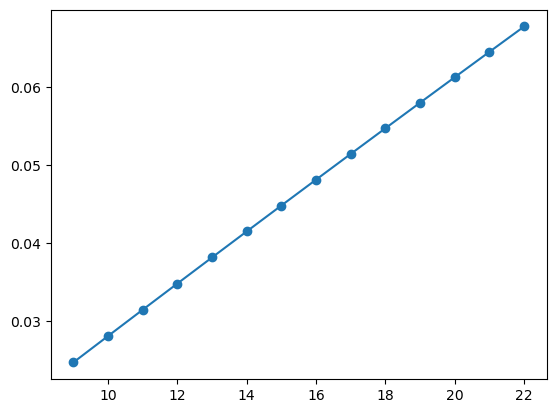

In [106]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### numerical: via simulated residual plots

Detected peaks Distribution by simulation
 - Simulating SEDs (Residuals) based on the numbers of obs with the given data points,
 - which could be multiplied to around 1000 observations
 - Detect the peaks
 - Repeat 1000 times
 - Obtain the distribution of the number of detected peaks

In [107]:

import numpy as np

def draw_detectedPeaks_distribution(array_nbins, array_nobs, normalization=True, ntrials=1000):
  # nconsecutive = 3

  sample_normalization_factor = 1.0
  if normalization:
    sample_normalization_factor = int(1000./np.sum(array_nobs))+1
    print(1000.0/np.sum(array_nobs))
    print('sample_normalization_factor', sample_normalization_factor)

  sample_size = int(np.sum(array_nbins*array_nobs*sample_normalization_factor)*ntrials)
  array_nobs = array_nobs * sample_normalization_factor
  print('sample_size', sample_size)
  print('bins = ', array_nbins)
  print('nobs = ', array_nobs)

  #############################################
  #  Simulate all the data points of all SEDs (assuming residual plots)
  #############################################
  mu, sigma = 0, 1.0
  s = np.random.normal(mu, sigma, sample_size)

  #############################################
  #  Peak detection and counting
  #############################################
  arr_n_detected_peaks = []
  for initpos_sample, i_trial in zip(range(0,sample_size,ntrials),range(ntrials)):    
    n_detected_peaks = 0
    pos_sample = initpos_sample
    for i_nbins,i_nobs in zip(array_nbins, array_nobs):        
      for i in range(pos_sample,int(pos_sample+i_nbins*i_nobs),int(i_nbins)):          
        # print(pos_sample, i_nbins, i_nobs, i)
        # print(s[i:i+int(i_nbins)])
        peakbininit = get_consecutive_bins(s[i:i+int(i_nbins)],nconsecutive)
        if peakbininit >= 0:
          # print('A peak detected at the bin #',peakbininit)
          # plt.plot(range(peakbininit, nbins),s[i+peakbininit:i+nbins], label='obs'+str(j), marker='o',linestyle='')
          # plt.plot(range(peakbininit, peakbininit+nconsecutive),s[i+peakbininit:i+peakbininit+3], label='obs'+str(j), marker='o',linestyle='-')
          n_detected_peaks += 1
          # plt.plot(range(nbins),s[i:i+nbins], label='obs'+str(j))
      pos_sample += int(i_nbins*i_nobs)
    arr_n_detected_peaks.append(n_detected_peaks)
    print('trial',i_trial, ': n_detected_peaks=', n_detected_peaks)
  # print('Detected peaks are ', arr_n_detected_peaks)
  #############################################
  #  Fit a Gaussian distribution to the data
  #############################################
  # draw a histogram of arr_n_detected_peaks
  import matplotlib.pyplot as plt
  # plt.hist(arr_n_detected_peaks, bins=20)
  # plt.xlabel('Number of observations with detected peaks')
  # plt.ylabel('Frequency')
  # plt.title('Histogram of probability of detecting a peak')
  # plt.show()  
  from scipy.optimize import curve_fit
  nbins = 20
  n, bins, patches = plt.hist(arr_n_detected_peaks, bins = nbins)
  plt.xlabel('Number of observations with detected peaks')
  plt.ylabel('# Trials')
  plt.title('Histogram of the number of detected peaks for '+str(ntrials)+' trials')
  # plt.show()
  print('-- Distribution of number of detected peaks --')
  print('mean : ',np.mean(arr_n_detected_peaks))
  print('std  : ',np.std(arr_n_detected_peaks))
  #############################################
  #  Fit a Gaussian distribution to the data
  #############################################
#   xmin, xmax = plt.xlim()
#   x = np.linspace(xmin, xmax, nbins)
#   y = n
#   popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
#   # popt, pcov = curve_fit(gaussian, x, y)

#   plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
#   print('amplitude', popt[0])
#   print('mu', popt[1])
#   print('sigma', popt[2])
#   plt.yscale('log')
  plt.show()

## - Peak detection on real data

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit




def eval_spectra(filepath): #'data/3C454.3_allsed_14d_min11.ecsv'
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  t_residual = Table()
  t_fitparams = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)

    ### fit the data  ###
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      residuals = (y-fitted_line(x))/yerr
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    
    residuals = (y-fitted_line(x))/yerr
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    # peakbininit = get_consecutive_bins(residuals,nconsecutive)
    peakinitbins, peaklengths = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    # t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)],
    #                         names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    # t_residual = vstack([t_residual,t_residual_ind])

    # Extract y value where x (e_ref) is closest to 100 MeV
    idx_100mev = np.argmin(np.abs(x - 100.0))
    y_at_100mev = y[idx_100mev]

    # Extract y value where x (e_ref) is closest to 200 MeV
    idx_200mev = np.argmin(np.abs(x - 200.0))
    y_at_200mev = y[idx_200mev]
    
    # FIX: Wrap scalar values in lists for Table creation
    t_fitparams_ind = Table(
        [[obsdate], [nbins], [fitted_line.amplitude.value], [fitted_line.x_0.value], 
         [fitted_line.alpha.value], [fitted_line.beta.value], [y_at_200mev], [y_at_100mev]],
        names=["obsdate", "nbins","amplitude", "x_0", "alpha", "beta", "y_200MeV", "y_100MeV"])
    # t_fitparams_ind = Table([obsdate, nbins, fitted_line.amplitude.value, fitted_line.x_0.value, fitted_line.alpha.value, fitted_line.beta.value],
    #                         names=["obsdate", "nbins","amplitude", "x_0", "alpha", "beta"])
    t_fitparams = vstack([t_fitparams, t_fitparams_ind])

    if len(peakinitbins) > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      plotSED(x, y , yerr, fitted_line,  peakinitbins, peaklengths, residuals, reduced_chi_squared, obsdate, idx)
      for peakbininit, peaklength in zip(peakinitbins, peaklengths):
        print(residuals[peakbininit:peakbininit+peaklength])
      # plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
      # plt.plot(x,fitted_line(x),'-')
      # plt.plot(x[peakbininit:peakbininit+nconsecutive],
      #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')

      # plt.title('obs'+str(idx)+':MJD'+str(int(obsdate)))
      # plt.xlabel('Energy [MeV]')
      # plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.show()

  ### bin数分布 ###
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  print('nbins distribution:')
  print(  hist_nbins[0], hist_nbins[1][0:-1]+0.5, hist_nbins[2])
  plt.show()
  
  # ### detected peaks 分布 ###
  # draw_detectedPeaks_distribution(hist_nbins[1][0:-1]+0.5,hist_nbins[0])
  # plt.show()

  ### nbins vs curvature beta ###
  plt.plot(t_fitparams['nbins'], t_fitparams['beta'],'.')
  plt.xlabel('Number of effective bins')
  plt.ylabel('Curvature beta')
  plt.show()

  ### amplitude vs curvature beta ###
  plt.plot(t_fitparams['amplitude'], t_fitparams['beta'],'.')
  plt.xlabel('Amplitude')
  plt.ylabel('Curvature beta')
  plt.xscale('log')
  plt.show()

  ### flux at 200 MeV vs curvature beta ###
  plt.plot(t_fitparams['y_200MeV'], t_fitparams['beta'],'.')
  plt.xlabel('Flux at 200 MeV [MeV cm^-2 s^-1]')
  plt.ylabel('Curvature beta')
  plt.xscale('log')
  plt.show()

  ### flux at 100 MeV vs curvature beta ###
  plt.plot(t_fitparams['y_100MeV'], t_fitparams['beta'],'.')
  plt.xlabel('Flux at 100 MeV [MeV cm^-2 s^-1]')
  plt.ylabel('Curvature beta')
  plt.xscale('log')
  plt.show()

  ### obsdate vs curvature beta ###
  plt.plot(t_fitparams['obsdate'], t_fitparams['beta'],'.')
  plt.xlabel('Observation date (MJD)')
  plt.ylabel('Curvature beta')
  plt.show()
  
  ### obsdate vs curvature beta ###
  fig, ax = plt.subplots()
  ax.plot(t_fitparams['obsdate'], t_fitparams['beta'], '.', label='β')
  ax.set_xlabel('Observation date (MJD)')
  ax.set_ylabel('Curvature β')

  # --- overlay flux from the CSV file ----------------------------------
  import os
  csv_path = os.path.join('data_LC', '4fgl-j092402816.csv')
  if os.path.exists(csv_path):
      tbl_csv = Table.read(csv_path, format='csv')

      # strip BOM and surrounding quotes/whitespace from the column names
      cleaned = [name.lstrip('\ufeff').strip().strip('"')
                 for name in tbl_csv.colnames]
      # apply the cleaned names
      for old, new in zip(tbl_csv.colnames, cleaned):
          tbl_csv.rename_column(old, new)
      # print("csv columns:", tbl_csv.colnames)          # debug if needed


      # header is
      # "Modified Julian Date","Detection","Upper Limit","Error (low)","Error (high)"
      if 'obsdate' in tbl_csv.colnames:
          x_csv = tbl_csv['obsdate']
      elif 'Modified Julian Date' in tbl_csv.colnames:
          x_csv = tbl_csv['Modified Julian Date']      # ← this branch is taken
      else:
          raise KeyError(f"no obsdate/MJD column in {csv_path}: "
                         f"{tbl_csv.colnames}")  
      

      for cand in ('flux', 'Flux', 'FLUX', 'Detection'):
          if cand in tbl_csv.colnames:
              y_csv = tbl_csv[cand]                   # ← picks up `Detection`
              break

      ax2 = ax.twinx()
      ax2.plot(x_csv, y_csv, 'r.', label='flux')
      ax2.set_ylabel('Flux')
      # combine legends from both axes
      lines, labels = ax.get_legend_handles_labels()
      lines2, labels2 = ax2.get_legend_handles_labels()
      ax.legend(lines + lines2, labels + labels2, loc='best')
  else:
      print(f'{csv_path} not found')
  # ---------------------------------------------------------------------

  plt.show()
  # ### 各Eの residual 分布 ###
  # plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  # plt.xscale('log')
  # plt.show()

  
  # ### residual 分布 ###
  # # plt.hist(t_residual['residual'], bins = 30)
  # # plt.yscale('log')  
  # # plt.show()
  # n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # # plt.show()

  # # Fit a gaussian distribution to the data:
  # xmin, xmax = plt.xlim()
  # x = np.linspace(xmin, xmax, len(bins)-1)
  # y = n
  # popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # # popt, pcov = curve_fit(gaussian, x, y)

  # plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  # ymin, ymax = plt.ylim()
  # plt.ylim(0.8,ymax)
  # print('amplitude', popt[0])
  # print('mu', popt[1])
  # print('sigma', popt[2])
  # plt.yscale('log')
  # plt.show()

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()


  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))

# ★★★ Execution on the data

/tmp/ipykernel_6288/4004085784.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


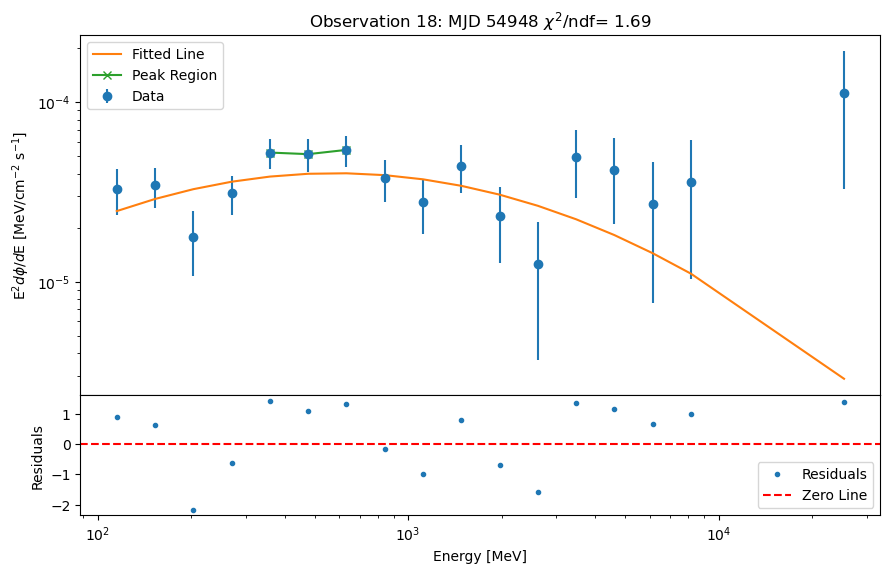

      e2dnde      
  MeV / (s cm2)   
------------------
 1.426329606289444
1.0755704019329038
1.3031620886145485


/tmp/ipykernel_6288/4004085784.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


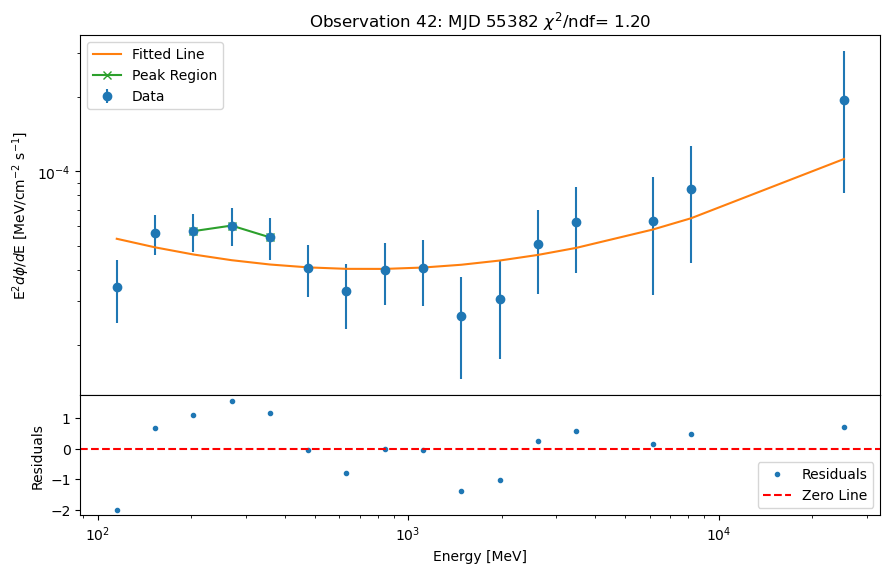

      e2dnde      
  MeV / (s cm2)   
------------------
1.1215838482715543
1.5824725189728794
1.1638470129324923


/tmp/ipykernel_6288/4004085784.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


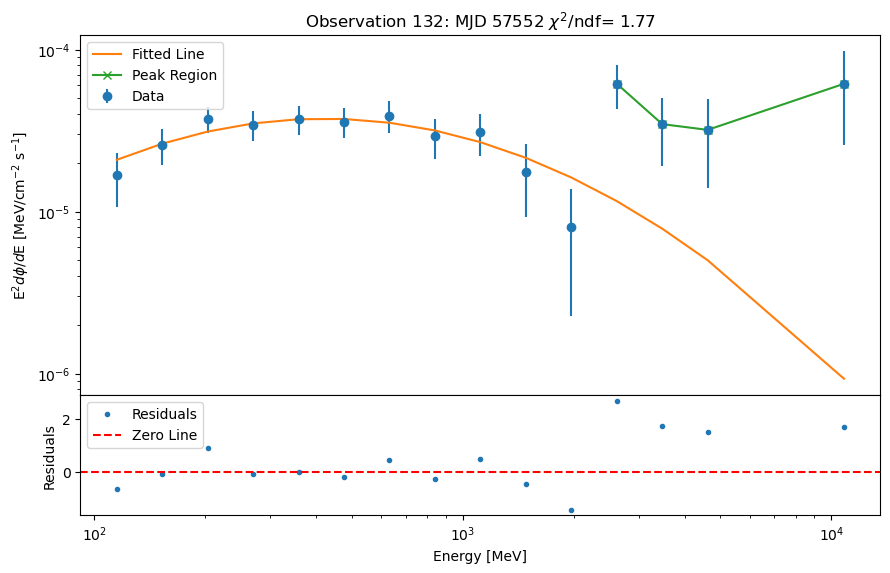

      e2dnde      
  MeV / (s cm2)   
------------------
  2.69948665326038
 1.734080565881774
1.5078439965359913
1.6918043702112087
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8


/tmp/ipykernel_6288/4004085784.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


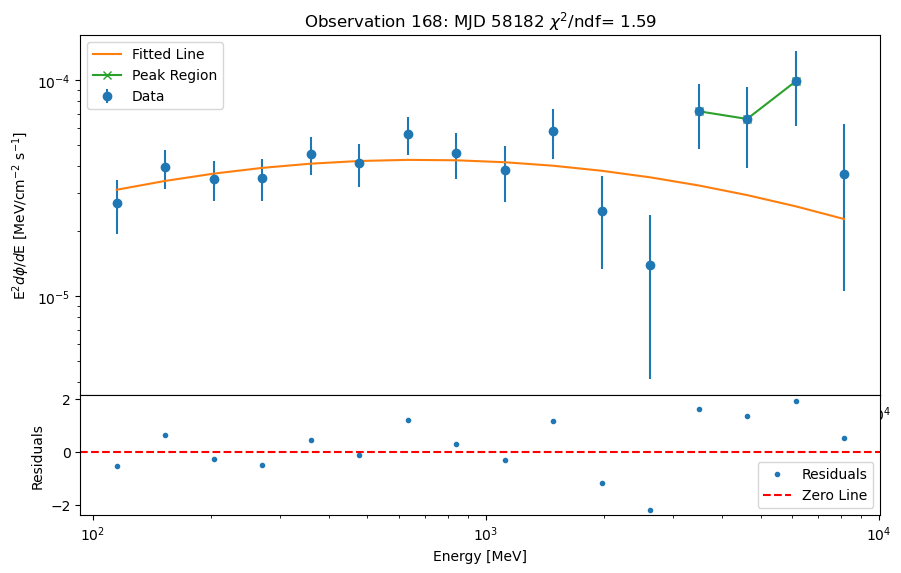

      e2dnde      
  MeV / (s cm2)   
------------------
1.6381987731415681
1.3561399479151557
1.9552923289630835


/tmp/ipykernel_6288/4004085784.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


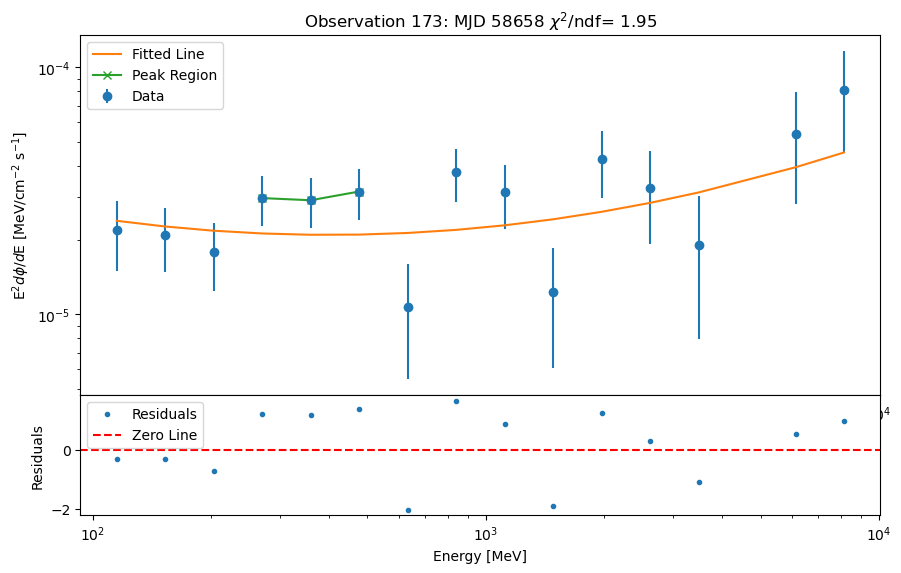

      e2dnde      
  MeV / (s cm2)   
------------------
1.2369046958123666
 1.217554553699748
1.4151635215056333
nbins < nbinsmin: 8
nbins distribution:
[ 8. 15. 19. 26. 24. 32. 27. 15. 16.  6.  5.  0.  0.  0.] [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.] [<matplotlib.patches.Polygon object at 0x79d272c44850>]


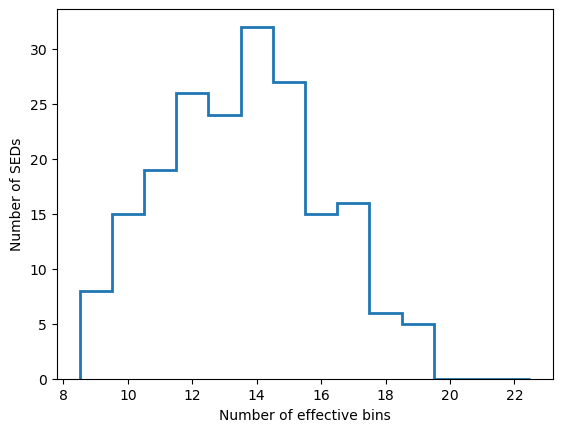

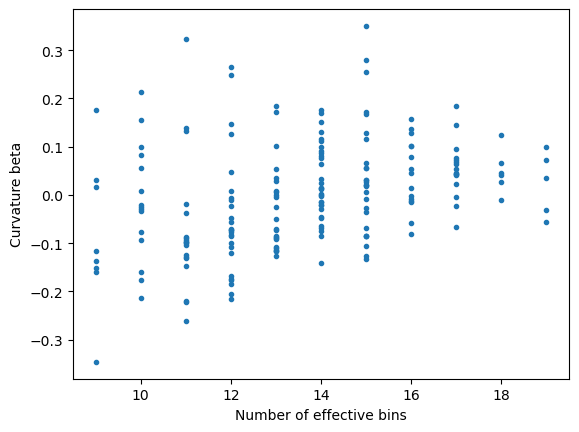

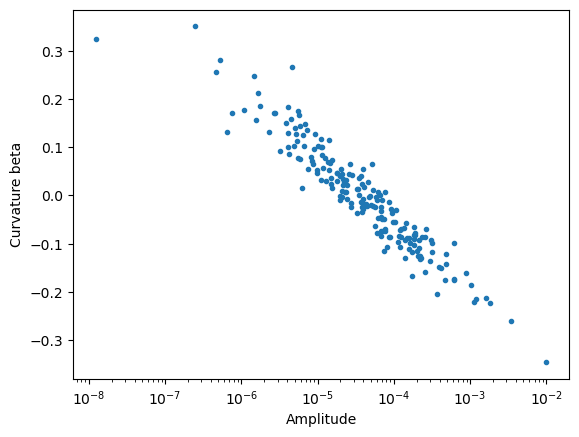

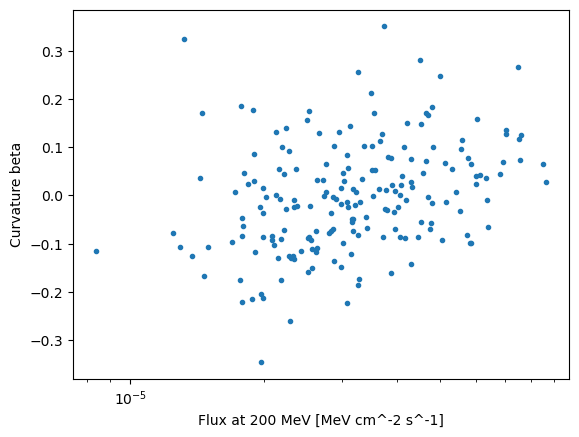

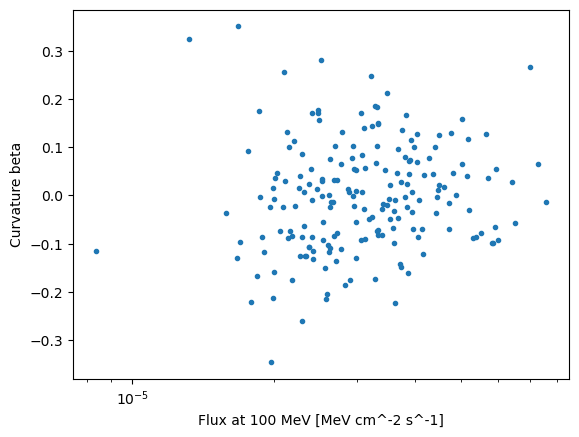

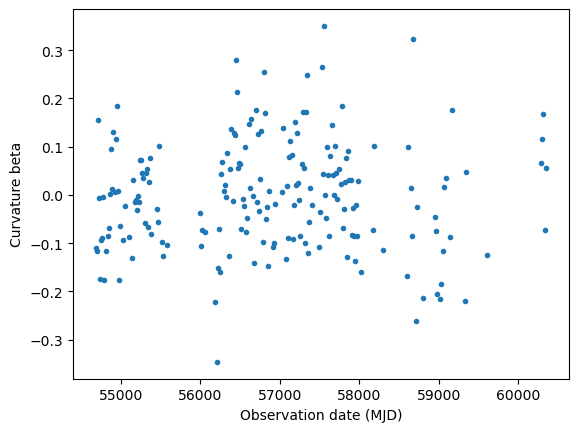

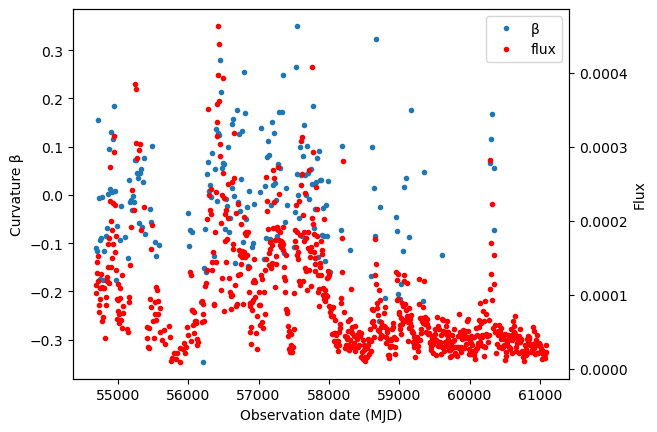

Number of detected peaks: 5
Number of used SEDs: 193
Number of SEDs: 197
Weighted average of the probability from theory:  0.04009735726819049


In [109]:
eval_spectra('data/PKS0426-380_allsed_14d_min11.ecsv')    # 3pos, /183
